In [2]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt

### Part 1

------------------------------
t 	 f
------------------------------
0        2.0     
1        0.9540660363145945
2        0.6886356849243735
3        0.5512903882706928
4        0.4496644267451241
5        0.3679248411012048
6        0.30120035612455537
7        0.24659779547032554
8        0.2018966305298301
9        0.16529890345156628
10       0.1353352852977663
11       0.11080315864128068
12       0.09071795332716381
13       0.07427357821944297
14       0.06081006262590939
15       0.04978706836795752
16       0.040762203978378875
17       0.03337326996032778
18       0.02732372244729279
19       0.022370771856165622


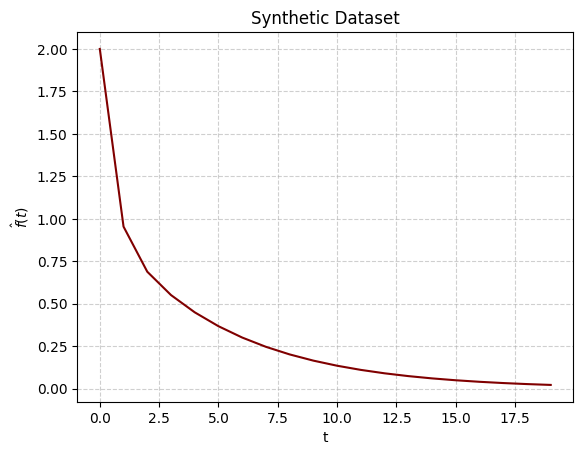

In [27]:
# parameters
a1 = 1.0
a2 = 1.0
b1 = -2.0
b2 = -0.20

# time parameters
t0 = 0
dt = 1 
N = 20

# generating the dataset
t = np.arange(N) * dt 
f = a1 * np.exp(b1*t) + a2 * np.exp(b2*t)

# Print the synthetic dataset
# Print the synthetic dataset
print('------------------------------')
print("t \t f")
print('------------------------------')
for ti, fi in zip(t, f):
    print(f"{ti:<8} {fi:<8}")  

    
# plotting the synthetic dataset
plt.plot(t,f,color='maroon')
plt.xlabel('t')
plt.ylabel(r'$\hat{f}(t)$')
plt.title("Synthetic Dataset")
plt.grid(True,linestyle='--',alpha = 0.6)

### Part 2

a1=  0.999999999999999
a2=  1.0000000000000002


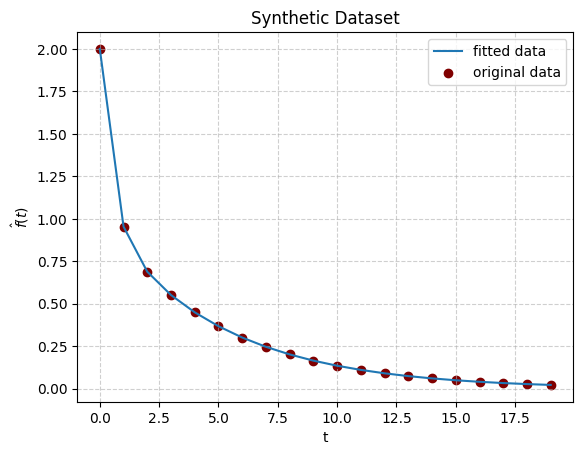

In [4]:
u1 = np.exp(b1*t)
u2 = np.exp(b2*t)

# setting up the matrix for LLS
A = np.zeros([N,2])
for i in range(N):
    A[i,0] = u1[i] 
    A[i,1] = u2[i]

# solving the system A'Ax = A'b 
# x matrix is to be solved and contains a1 and a2 
# f forms matrix b
x = np.linalg.solve(A.transpose() @ A, A.transpose() @ f)
print('a1= ', x[0])
print('a2= ', x[1])

fit = x[0] * u1 + x[1] * u2
plt.plot(t,fit, label='fitted data')
plt.scatter(t,f,color='maroon', label='original data')
plt.xlabel('t')
plt.ylabel(r'$\hat{f}(t)$')
plt.title("Synthetic Dataset")
plt.grid(True,linestyle='--',alpha = 0.6)
plt.legend()

### Part 4

In [14]:
# setting up the matrix for LLS
A = np.zeros([N-2,2])
for i in range(N-2):
    A[i,0] = f[i+1] 
    A[i,1] = f[i]

# solving the system A'Ad = A'b 
# d matrix is to be solved and contains d1 and d2 
# f forms matrix b
d = np.linalg.solve(A.transpose() @ A, A.transpose() @ f[2:N])
print("d estimate:")
print('d1 = ', d[0])
print('d2 = ', d[1])

# calculating u1 and u2
u1 = (d[0] + np.sqrt(d[0]*d[0]+4*d[1])) / 2.0
u2 = d[0] - (d[0] + np.sqrt(d[0]*d[0]+4*d[1])) / 2.0

print("\n")
print("u estimate:")
print('u1 = ', u1)
print('u2 = ', u2)

print("\n")
print("b estimate:")
print('b1 = ', np.log(u1))
print('b2 = ', np.log(u2))

d estimate:
d1 =  0.9540660363145926
d2 =  -0.11080315836233284


u estimate:
u1 =  0.818730753077981
u2 =  0.1353352832366116


b estimate:
b1 =  -0.20000000000000098
b2 =  -2.000000000000008


### Part 5

a1=  1.0000000000000033
a2=  0.999999999999997


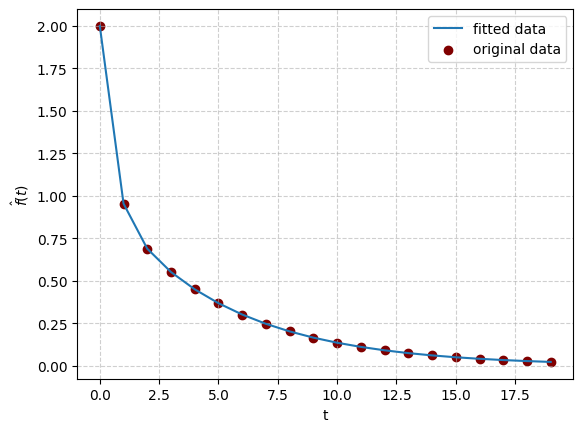

In [18]:
# setting up the matrix for LLS
A = np.zeros([N,2])
for i in range(N):
    A[i,0] = u1**(i) 
    A[i,1] = u2**(i)

# solving the system A'Ax = A'b 
# x matrix is to be solved and contains a1 and a2 
# f forms matrix b
a = np.linalg.solve(A.transpose() @ A, A.transpose() @ f)
print('a1= ', a[0])
print('a2= ', a[1])

# Initialize fit array
fit = np.zeros(N)

for i in range(N):
    fit[i] = a[0] * u1**(i) + a[1] * u2**(i)

plt.plot(t,fit, label='fitted data')
plt.scatter(t,f,color='maroon', label='original data')
plt.xlabel('t')
plt.ylabel(r'$\hat{f}(t)$')
plt.grid(True,linestyle='--',alpha = 0.6)
plt.legend()